# KITTI Dataset: Comprehensive EDA Notebook

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1) Locate KITTI Directories

In [2]:
def find_repo_root(start: Path, marker: str = "pyproject.toml") -> Path:
    current = start.resolve()
    for p in [current] + list(current.parents):
        if (p / marker).exists():
            return p
    raise FileNotFoundError(f"Could not find repository root containing {marker}")

cwd = Path.cwd()
repo_root = find_repo_root(cwd)

kitti_raw_root = repo_root / "data" / "raw" / "KITTI"
train_image_dir = kitti_raw_root / "training" / "image_2"
train_label_dir = kitti_raw_root / "training" / "label_2"
test_image_dir = kitti_raw_root / "testing" / "image_2"

print(f"Repository root: {repo_root}")
print(f"Train images: {train_image_dir}")
print(f"Train labels: {train_label_dir}")
print(f"Test images:  {test_image_dir}")

for p in [train_image_dir, train_label_dir, test_image_dir]:
    print(f"Exists [{p.name}]: {p.exists()}")

Repository root: /home/abdallah/Coding/DEPI-Project/Road-Sense
Train images: /home/abdallah/Coding/DEPI-Project/Road-Sense/data/raw/KITTI/training/image_2
Train labels: /home/abdallah/Coding/DEPI-Project/Road-Sense/data/raw/KITTI/training/label_2
Test images:  /home/abdallah/Coding/DEPI-Project/Road-Sense/data/raw/KITTI/testing/image_2
Exists [image_2]: True
Exists [label_2]: True
Exists [image_2]: True


## 2) File Inventory and Alignment Checks

In [3]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

train_images = sorted([p for p in train_image_dir.glob("*") if p.suffix.lower() in IMAGE_EXTS])
test_images = sorted([p for p in test_image_dir.glob("*") if p.suffix.lower() in IMAGE_EXTS])
train_labels = sorted(train_label_dir.glob("*.txt"))

train_img_ids = {p.stem for p in train_images}
train_lbl_ids = {p.stem for p in train_labels}

missing_labels = sorted(train_img_ids - train_lbl_ids)
missing_images = sorted(train_lbl_ids - train_img_ids)

inventory = pd.DataFrame({
    "Metric": [
        "Training images",
        "Training labels",
        "Testing images",
        "Train images without label",
        "Train labels without image"
    ],
    "Value": [
        len(train_images),
        len(train_labels),
        len(test_images),
        len(missing_labels),
        len(missing_images)
    ]
})

display(inventory)

if missing_labels:
    print("Sample image IDs with missing labels:", missing_labels[:10])
if missing_images:
    print("Sample label IDs with missing images:", missing_images[:10])

,Metric,Value
0,Training images,7481
1,Training labels,7481
2,Testing images,7518
3,Train images without label,0
4,Train labels without image,0


## 3) Parse KITTI Labels into a Structured DataFrame

In [4]:
KITTI_COLUMNS = [
    "class", "truncated", "occluded", "alpha",
    "xmin", "ymin", "xmax", "ymax",
    "h", "w", "l", "x", "y", "z", "rotation_y"
]

def parse_kitti_line(line: str):
    parts = line.strip().split()
    if len(parts) != 15:
        return None
    out = {"class": parts[0]}
    numeric = [
        "truncated", "occluded", "alpha",
        "xmin", "ymin", "xmax", "ymax",
        "h", "w", "l", "x", "y", "z", "rotation_y"
    ]
    for key, val in zip(numeric, parts[1:]):
        out[key] = float(val)
    out["occluded"] = int(out["occluded"])
    return out

records = []
bad_lines = 0

for label_path in train_labels:
    image_id = label_path.stem
    with open(label_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            parsed = parse_kitti_line(line)
            if parsed is None:
                bad_lines += 1
                continue
            parsed["image_id"] = image_id
            parsed["label_file"] = label_path.name
            parsed["line_no"] = line_no
            records.append(parsed)

df = pd.DataFrame(records)

print(f"Parsed objects: {len(df):,}")
print(f"Malformed lines skipped: {bad_lines}")
display(df.head())

Parsed objects: 51,865
Malformed lines skipped: 0


,class,truncated,occluded,alpha,xmin,ymin,xmax,ymax,h,w,l,x,y,z,rotation_y,image_id,label_file,line_no
0,Pedestrian,0.0,0,-0.20,712.40,143.00,810.73,307.92,1.89,0.48,1.20,1.84,1.47,8.41,0.01,000000,000000.txt,1
1,Truck,0.0,0,-1.57,599.41,156.40,629.75,189.25,2.85,2.63,12.34,0.47,1.49,69.44,-1.56,000001,000001.txt,1
2,Car,0.0,0,1.85,387.63,181.54,423.81,203.12,1.67,1.87,3.69,-16.53,2.39,58.49,1.57,000001,000001.txt,2
3,Cyclist,0.0,3,-1.65,676.60,163.95,688.98,193.93,1.86,0.60,2.02,4.59,1.32,45.84,-1.55,000001,000001.txt,3
4,DontCare,-1.0,-1,-10.00,503.89,169.71,590.61,190.13,-1.00,-1.00,-1.00,-1000.00,-1000.00,-1000.00,-10.00,000001,000001.txt,4


## 4) Feature Engineering for Better EDA

In [5]:
df["bbox_width"] = df["xmax"] - df["xmin"]
df["bbox_height"] = df["ymax"] - df["ymin"]
df["bbox_area"] = df["bbox_width"] * df["bbox_height"]
df["bbox_aspect_ratio"] = df["bbox_width"] / df["bbox_height"].replace(0, np.nan)
df["bbox_center_x"] = (df["xmin"] + df["xmax"]) / 2
df["bbox_center_y"] = (df["ymin"] + df["ymax"]) / 2

# A simple quality flag for invalid boxes
df["invalid_bbox"] = (df["bbox_width"] <= 0) | (df["bbox_height"] <= 0)

summary = {
    "Total images (train)": len(train_images),
    "Total objects": int(len(df)),
    "Unique classes": int(df["class"].nunique()),
    "Images with at least 1 object": int(df["image_id"].nunique()),
    "Objects per labeled image (mean)": round(df.groupby("image_id").size().mean(), 2),
    "Invalid bounding boxes": int(df["invalid_bbox"].sum())
}

display(pd.DataFrame(summary, index=["Value"]))

,Total images (train),Total objects,Unique classes,Images with at least 1 object,Objects per labeled image (mean),Invalid bounding boxes
Value,7481,51865,9,7481,6.93,0


## 5) Class Distribution (Including Long Tail)

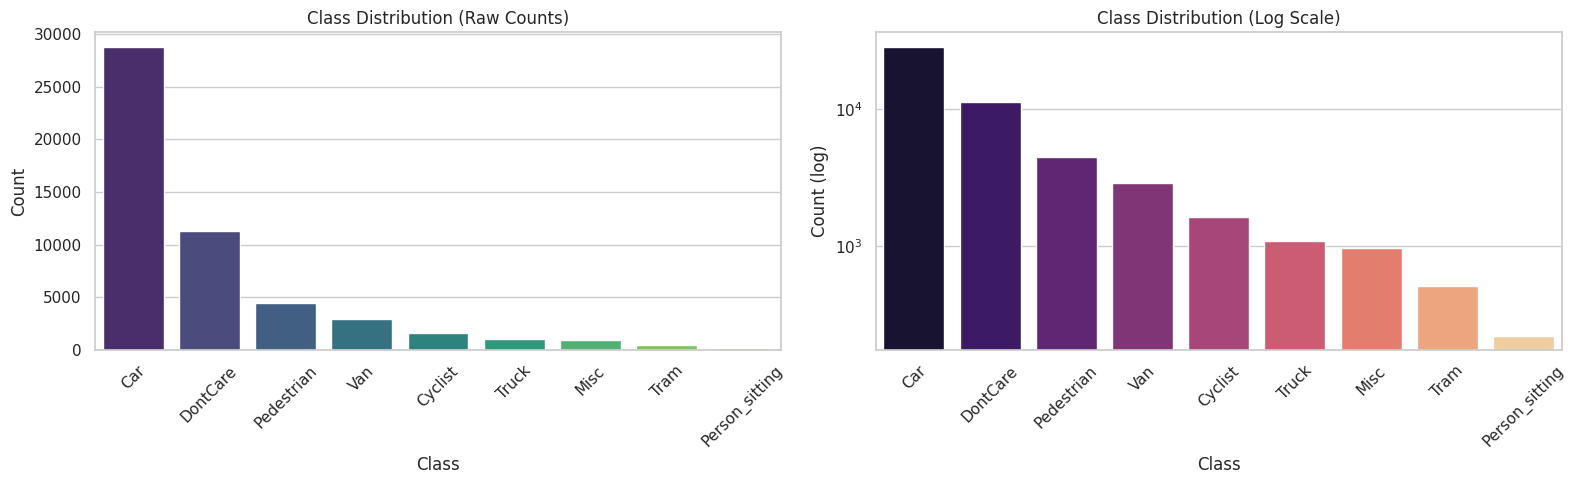

,class,count
0,Car,28742
1,DontCare,11295
2,Pedestrian,4487
3,Van,2914
4,Cyclist,1627
5,Truck,1094
6,Misc,973
7,Tram,511
8,Person_sitting,222


In [6]:
class_counts = df["class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Class Distribution (Raw Counts)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1], palette="magma")
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count (log)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(class_counts.rename_axis("class").reset_index(name="count"))

## 5.1) Project Class Mapping and Filtering

Apply the Road-Sense class strategy:
- Merge `Car`, `Van`, `Truck` into class `0` (`Vehicle`)
- Merge `Pedestrian`, `Person_sitting` into class `1` (`Pedestrian`)
- Keep `Cyclist` as class `2`
- Exclude `DontCare`, `Misc`, `Tram`
- Filter very small boxes with `min_bbox_size = 0.005` (0.5% of image area)

In [13]:
class_mapping = {
    "Car": 0,
    "Van": 0,
    "Truck": 0,
    "Pedestrian": 1,
    "Person_sitting": 1,
    "Cyclist": 2,
}

mapped_class_names = {
    0: "Vehicle",
    1: "Pedestrian",
    2: "Cyclist",
}

exclude_classes = {"DontCare", "Misc", "Tram"}
min_bbox_size = 0.005

# Estimate image area from training images (robust fallback).
if "median_w" not in globals() or "median_h" not in globals():
    sampled_images = random.sample(train_images, k=min(100, len(train_images)))
    sampled_sizes = [plt.imread(p).shape[:2] for p in sampled_images]
    if sampled_sizes:
        median_h = int(np.median([s[0] for s in sampled_sizes]))
        median_w = int(np.median([s[1] for s in sampled_sizes]))
    else:
        median_w, median_h = 1242, 375

image_area = float(median_w * median_h)

df_mapped = df.copy()
df_mapped["bbox_area_norm"] = df_mapped["bbox_area"] / image_area
df_mapped["is_excluded"] = df_mapped["class"].isin(exclude_classes)
df_mapped["is_mapped"] = df_mapped["class"].isin(class_mapping)
df_mapped["keep_bbox_size"] = df_mapped["bbox_area_norm"] >= min_bbox_size

df_final = df_mapped[
    (~df_mapped["is_excluded"]) &
    (df_mapped["is_mapped"]) &
    (df_mapped["keep_bbox_size"])
].copy()

df_final["class_id"] = df_final["class"].map(class_mapping).astype(int)
df_final["class_name"] = df_final["class_id"].map(mapped_class_names)

mapping_summary = pd.DataFrame({
    "Metric": [
        "Objects before filtering",
        "Removed by exclude_classes",
        "Removed by unmapped classes",
        "Removed by min_bbox_size",
        "Objects after filtering",
        "Retained ratio"
    ],
    "Value": [
        len(df_mapped),
        int(df_mapped["is_excluded"].sum()),
        int((~df_mapped["is_mapped"]).sum()),
        int((~df_mapped["keep_bbox_size"]).sum()),
        len(df_final),
        f"{len(df_final) / max(len(df_mapped), 1):.2%}"
    ]
})

display(mapping_summary)
print(f"Estimated image size used for area normalization: {median_w}x{median_h}")
print(f"Applied min_bbox_size: {min_bbox_size} ({min_bbox_size*100:.2f}% of image area)")

,Metric,Value
0,Objects before filtering,51865
1,Removed by exclude_classes,12779
2,Removed by unmapped classes,12779
3,Removed by min_bbox_size,24973
4,Objects after filtering,24098
5,Retained ratio,46.46%


Estimated image size used for area normalization: 1242x375
Applied min_bbox_size: 0.005 (0.50% of image area)


## 5.2) Visualization After Mapping (Final Training Classes)

These plots show the class balance *after* applying your mapping, exclusions, and minimum box size filtering.

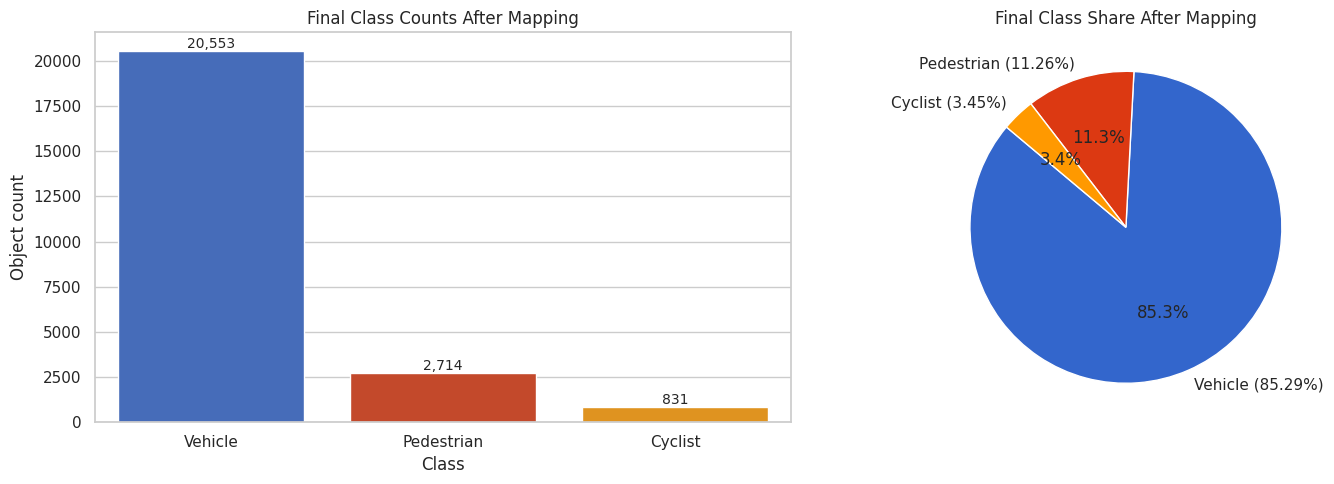

,class_name,class_id,count,percentage
0,Vehicle,0,20553,85.29
1,Pedestrian,1,2714,11.26
2,Cyclist,2,831,3.45


In [14]:
final_counts = df_final["class_name"].value_counts().reindex(["Vehicle", "Pedestrian", "Cyclist"]).fillna(0).astype(int)
final_pct = (final_counts / max(final_counts.sum(), 1) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=final_counts.index, y=final_counts.values, ax=axes[0], palette=["#3366cc", "#dc3912", "#ff9900"])
axes[0].set_title("Final Class Counts After Mapping")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Object count")
for i, v in enumerate(final_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

axes[1].pie(
    final_counts.values,
    labels=[f"{k} ({final_pct[k]}%)" for k in final_counts.index],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#3366cc", "#dc3912", "#ff9900"]
)
axes[1].set_title("Final Class Share After Mapping")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "class_name": final_counts.index,
    "class_id": [0, 1, 2],
    "count": final_counts.values,
    "percentage": final_pct.values
}))

## 5.3) Balance Step: Cap `Vehicle` to 3000 Samples

This step down-samples the dominant `Vehicle` class to improve class balance while keeping all other mapped classes unchanged.

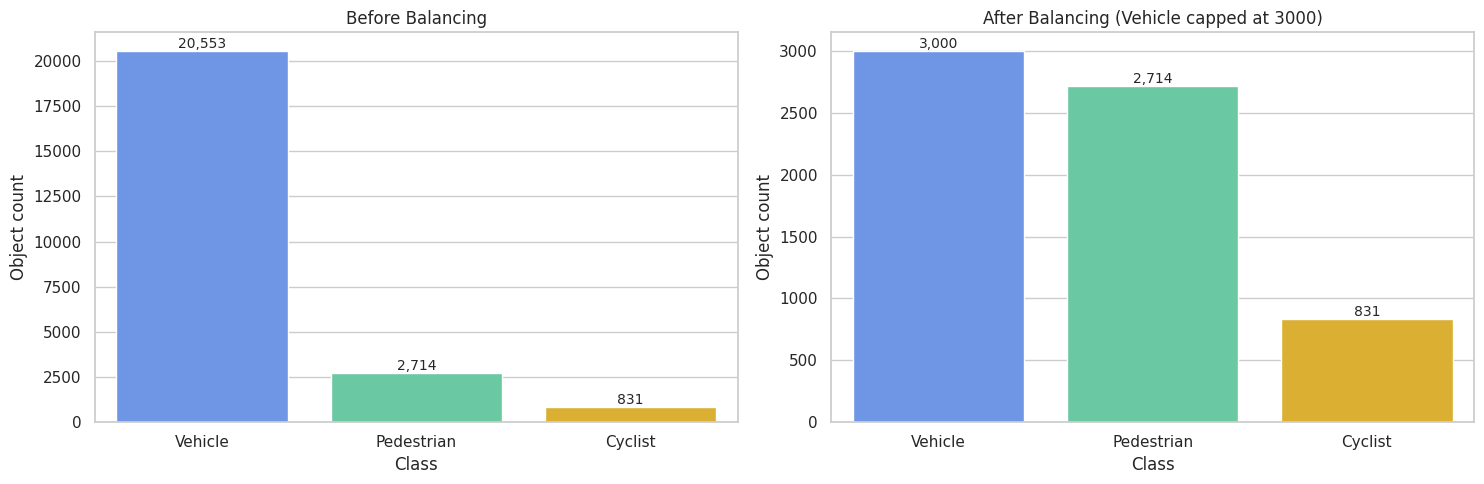

,class_name,before_count,after_count,change
0,Vehicle,20553,3000,-17553
1,Pedestrian,2714,2714,0
2,Cyclist,831,831,0


Vehicle cap applied: 3000
Balanced dataset size: 6,545


In [15]:
vehicle_cap = 3000
target_vehicle_class = "Vehicle"

vehicle_df = df_final[df_final["class_name"] == target_vehicle_class]
other_df = df_final[df_final["class_name"] != target_vehicle_class]

if len(vehicle_df) > vehicle_cap:
    vehicle_df_balanced = vehicle_df.sample(n=vehicle_cap, random_state=RANDOM_SEED)
else:
    vehicle_df_balanced = vehicle_df.copy()

df_balanced = pd.concat([vehicle_df_balanced, other_df], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

before_counts = df_final["class_name"].value_counts().reindex(["Vehicle", "Pedestrian", "Cyclist"]).fillna(0).astype(int)
after_counts = df_balanced["class_name"].value_counts().reindex(["Vehicle", "Pedestrian", "Cyclist"]).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=before_counts.index, y=before_counts.values, ax=axes[0], palette=["#5B8FF9", "#5AD8A6", "#F6BD16"])
axes[0].set_title("Before Balancing")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Object count")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

sns.barplot(x=after_counts.index, y=after_counts.values, ax=axes[1], palette=["#5B8FF9", "#5AD8A6", "#F6BD16"])
axes[1].set_title("After Balancing (Vehicle capped at 3000)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Object count")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

balance_summary = pd.DataFrame({
    "class_name": before_counts.index,
    "before_count": before_counts.values,
    "after_count": after_counts.values,
    "change": after_counts.values - before_counts.values,
})

display(balance_summary)
print(f"Vehicle cap applied: {vehicle_cap}")
print(f"Balanced dataset size: {len(df_balanced):,}")

# Optional: use this for downstream analysis/export if you want all next sections on balanced data.
analysis_df = df_balanced.copy()

## 6) Object Density Per Image

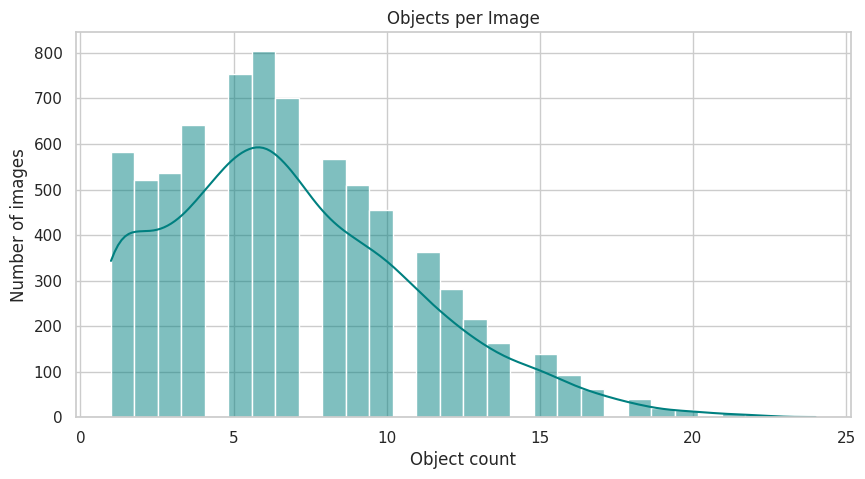

,count,mean,std,min,25%,50%,75%,max
object_count,7481.0,6.932897,4.078316,1.0,4.0,6.0,9.0,24.0


In [7]:
objects_per_image = df.groupby("image_id").size().rename("object_count")

plt.figure(figsize=(10, 5))
sns.histplot(objects_per_image, bins=30, kde=True, color="teal")
plt.title("Objects per Image")
plt.xlabel("Object count")
plt.ylabel("Number of images")
plt.show()

display(objects_per_image.describe().to_frame().T)

## 7) Bounding Box Geometry

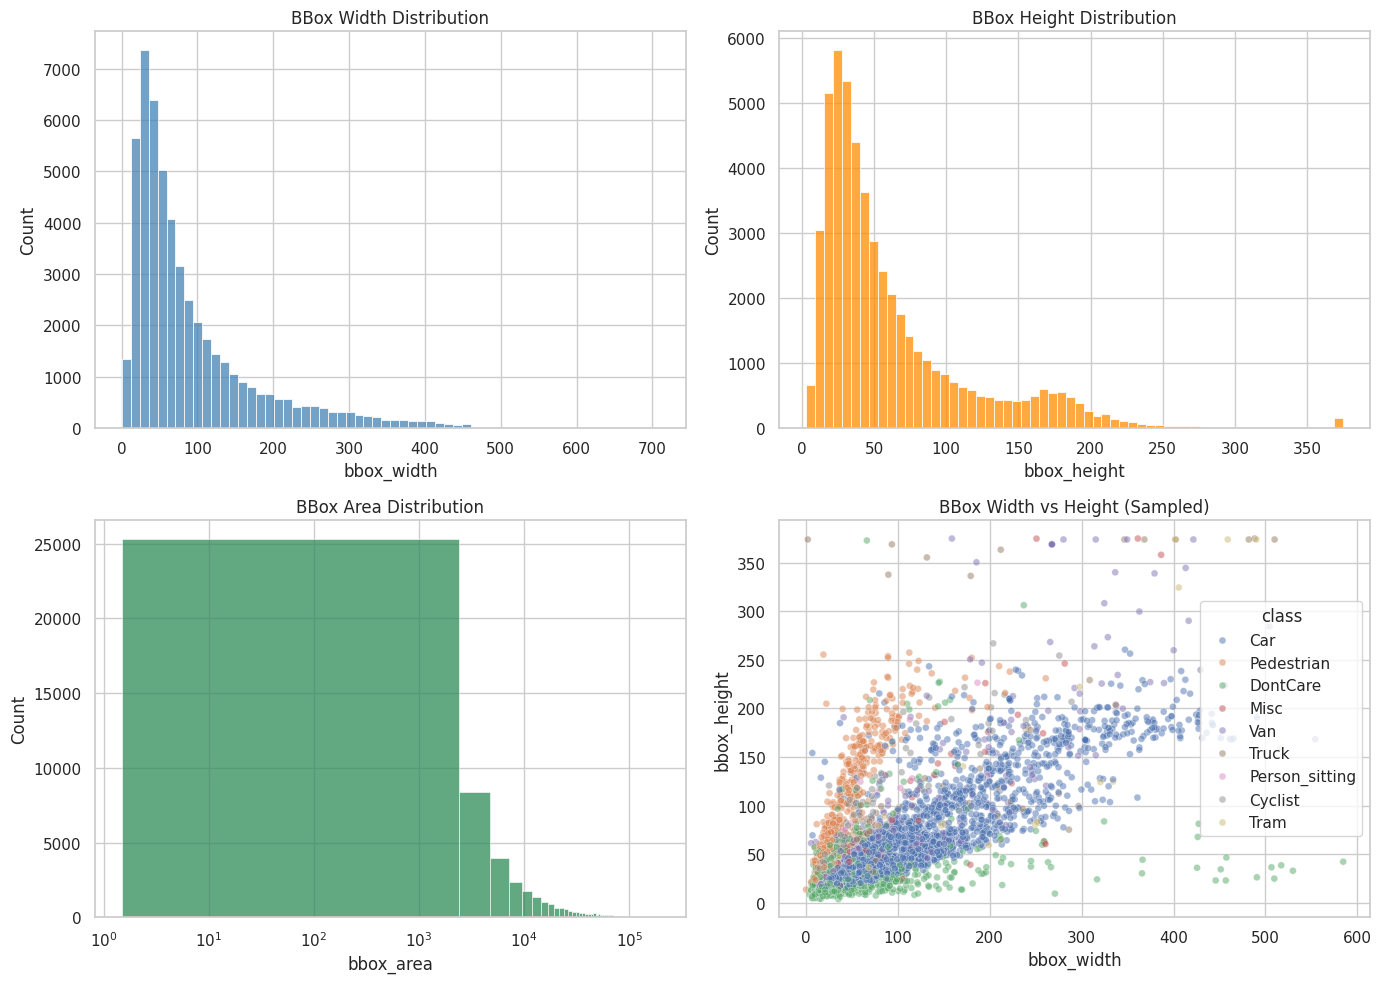

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["bbox_width"], bins=60, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("BBox Width Distribution")

sns.histplot(df["bbox_height"], bins=60, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("BBox Height Distribution")

sns.histplot(df["bbox_area"], bins=80, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("BBox Area Distribution")
axes[1, 0].set_xscale("log")

sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=RANDOM_SEED),
                x="bbox_width", y="bbox_height", hue="class", alpha=0.5, s=25, ax=axes[1, 1])
axes[1, 1].set_title("BBox Width vs Height (Sampled)")

plt.tight_layout()
plt.show()

## 8) Occlusion and Truncation Behavior

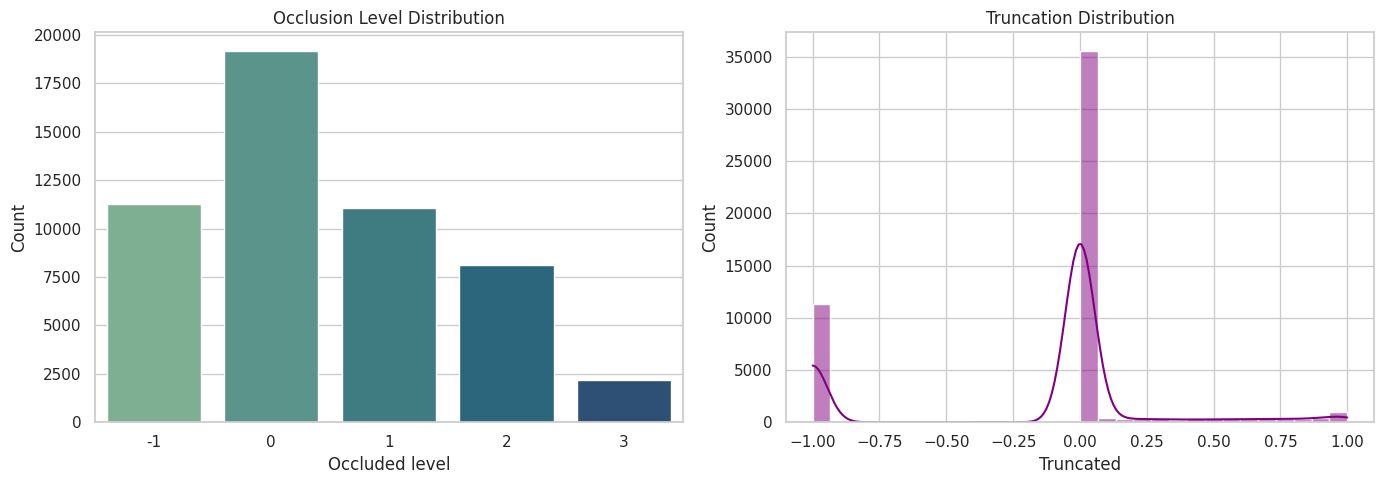

occluded,-1,0,1,2,3
class,,,,,
Car,0.00%,46.82%,28.47%,21.48%,3.23%
Cyclist,0.00%,62.08%,15.67%,4.92%,17.33%
DontCare,100.00%,0.00%,0.00%,0.00%,0.00%
Misc,0.00%,47.17%,24.77%,17.88%,10.17%
Pedestrian,0.00%,59.44%,24.40%,14.95%,1.20%
Person_sitting,0.00%,22.07%,34.23%,32.88%,10.81%
Tram,0.00%,45.99%,18.20%,24.07%,11.74%
Truck,0.00%,48.45%,24.95%,9.23%,17.37%
Van,0.00%,26.56%,29.96%,24.23%,19.25%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="occluded", palette="crest", ax=axes[0])
axes[0].set_title("Occlusion Level Distribution")
axes[0].set_xlabel("Occluded level")
axes[0].set_ylabel("Count")

sns.histplot(df["truncated"], bins=30, kde=True, color="purple", ax=axes[1])
axes[1].set_title("Truncation Distribution")
axes[1].set_xlabel("Truncated")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

occlusion_by_class = pd.crosstab(df["class"], df["occluded"], normalize="index")
display(occlusion_by_class.style.format("{:.2%}"))

## 9) Spatial Distribution of Objects (Center Heatmap)

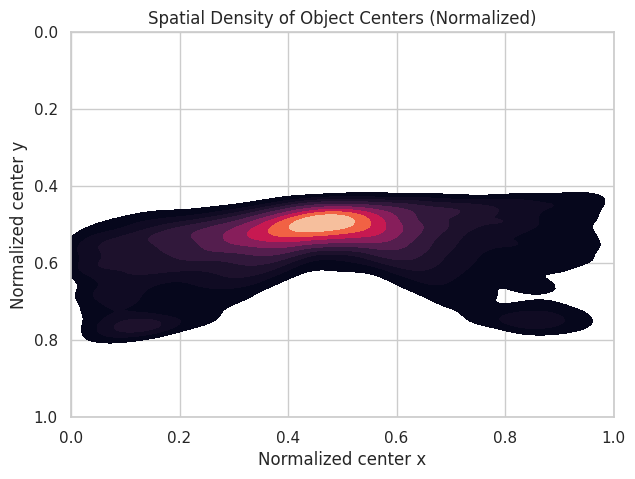

In [10]:
# Normalize centers by image resolution if available from coordinates.
# KITTI image sizes are mostly consistent, but normalization keeps the method general.
img_sizes = []
for p in random.sample(train_images, k=min(100, len(train_images))):
    arr = plt.imread(p)
    img_sizes.append((arr.shape[1], arr.shape[0]))

if img_sizes:
    median_w = int(np.median([w for w, _ in img_sizes]))
    median_h = int(np.median([h for _, h in img_sizes]))
else:
    median_w, median_h = 1242, 375

df["center_x_norm"] = df["bbox_center_x"] / median_w
df["center_y_norm"] = df["bbox_center_y"] / median_h

plt.figure(figsize=(7, 5))
sns.kdeplot(
    data=df,
    x="center_x_norm",
    y="center_y_norm",
    fill=True,
    cmap="rocket",
    thresh=0.05
)
plt.title("Spatial Density of Object Centers (Normalized)")
plt.xlabel("Normalized center x")
plt.ylabel("Normalized center y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().invert_yaxis()
plt.show()

## 10) Visual Sanity Check: Sample Images with Bounding Boxes

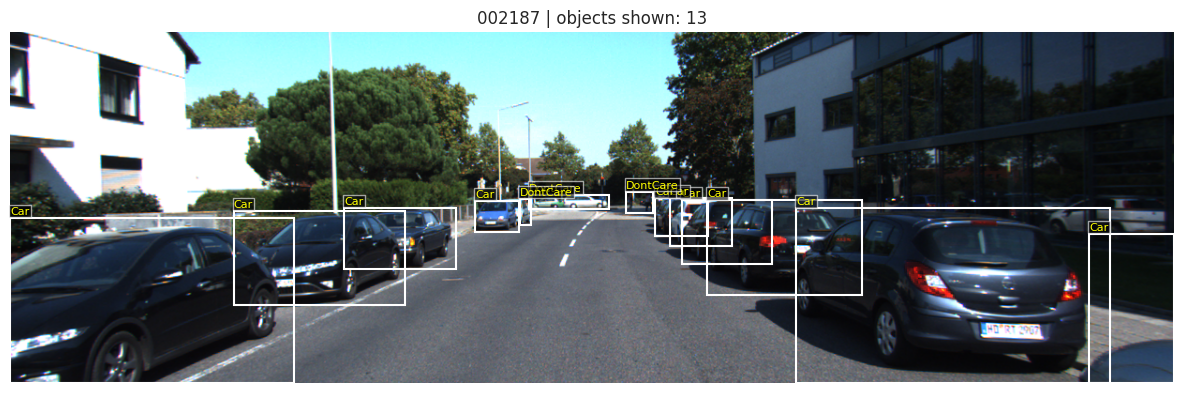

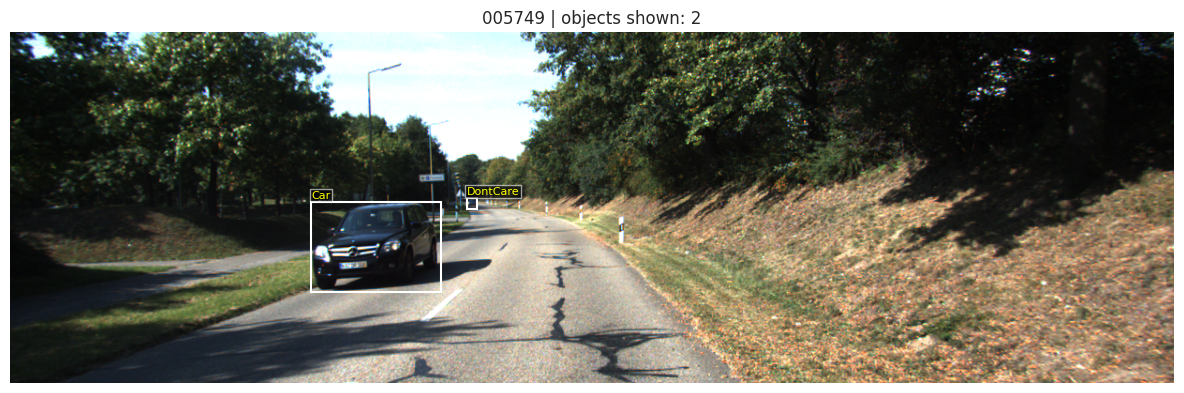

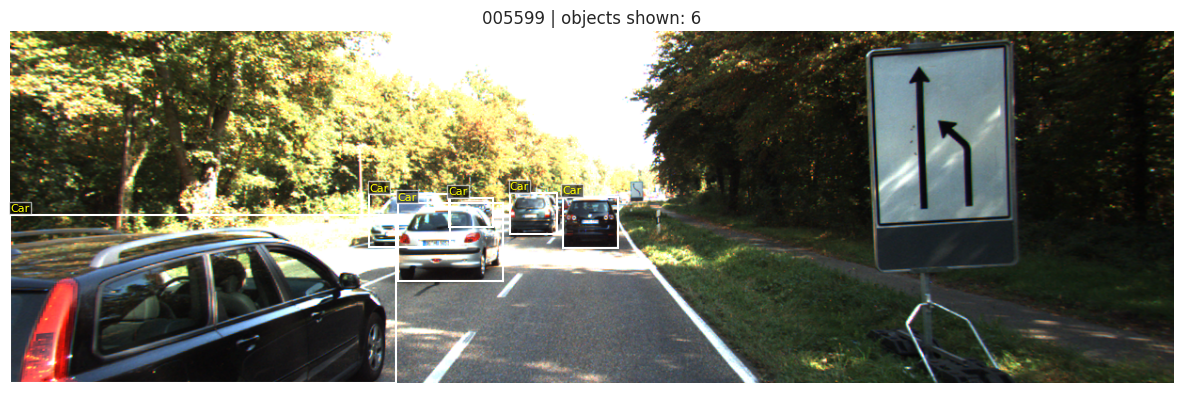

In [11]:
def draw_boxes_for_image(image_path: Path, label_df: pd.DataFrame, max_boxes: int = 30):
    image_id = image_path.stem
    rows = label_df[label_df["image_id"] == image_id].head(max_boxes)

    img = plt.imread(image_path)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img)

    for _, r in rows.iterrows():
        w = r["bbox_width"]
        h = r["bbox_height"]
        rect = Rectangle((r["xmin"], r["ymin"]), w, h, fill=False, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(r["xmin"], max(0, r["ymin"] - 4), r["class"], fontsize=8, color="yellow",
                bbox=dict(facecolor="black", alpha=0.6, pad=1))

    ax.set_title(f"{image_id} | objects shown: {len(rows)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

candidate_ids = sorted(set(df["image_id"]))
sample_ids = random.sample(candidate_ids, k=min(3, len(candidate_ids)))
for img_id in sample_ids:
    img_path = train_image_dir / f"{img_id}.png"
    if img_path.exists():
        draw_boxes_for_image(img_path, df)

## 11) Export Summary Tables for Reporting

In [12]:
out_dir = repo_root / "experiments" / "visualization" / "dataset_analysis"
out_dir.mkdir(parents=True, exist_ok=True)

class_counts_df = class_counts.rename_axis("class").reset_index(name="count")
image_density_df = objects_per_image.reset_index().rename(columns={"image_id": "image_id", "object_count": "object_count"})

class_counts_path = out_dir / "kitti_class_counts.csv"
density_path = out_dir / "kitti_objects_per_image.csv"

class_counts_df.to_csv(class_counts_path, index=False)
image_density_df.to_csv(density_path, index=False)

print(f"Saved: {class_counts_path}")
print(f"Saved: {density_path}")

Saved: /home/abdallah/Coding/DEPI-Project/Road-Sense/experiments/visualization/dataset_analysis/kitti_class_counts.csv
Saved: /home/abdallah/Coding/DEPI-Project/Road-Sense/experiments/visualization/dataset_analysis/kitti_objects_per_image.csv


## 12) Key Findings Template

Total images: 7481
Total objects: 40570
Average objects per image: 5.42
Images with no labels: 0

Image dimensions:
Width range: 1224 - 1242
Height range: 370 - 376

Class distribution:
Car                 : 28742 (70.85%)
Pedestrian          :  4487 (11.06%)
Van                 :  2914 ( 7.18%)
Cyclist             :  1627 ( 4.01%)
Truck               :  1094 ( 2.70%)
Misc                :   973 ( 2.40%)
Tram                :   511 ( 1.26%)
Person_sitting      :   222 ( 0.55%) 